# UHI Dataset EDA (LST + air_temperature)
This notebook reproduces the exploratory data analysis (EDA) for the four provided datasets:
- CAN_Full_UHI_Data.csv
- FIN_Full_UHI_Data.csv
- IRN_Full_UHI_Data.csv
- NGA_Full_UHI_Data.csv

Targets analyzed:
- **LST**
- **air_temperature**

Run cells from top to bottom.

In [ ]:

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # Optional: nicer display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

# import sys
# print(sys.executable)

# import sys
# !{sys.executable} -m pip install -U pip
# !{sys.executable} -m pip install pandas numpy matplotlib


## 1) Load data
Update `DATA_DIR` if your CSVs are stored elsewhere.

In [ ]:

from pathlib import Path

# Folder containing your CSVs
# If you're running this notebook in the same folder as the CSVs, you can use: DATA_DIR = Path(".")
DATA_DIR = "data"

paths = {
    "CAN": DATA_DIR / "CAN_Full_UHI_Data.csv",
    "FIN": DATA_DIR / "FIN_Full_UHI_Data.csv",
    "IRN": DATA_DIR / "IRN_Full_UHI_Data.csv",
    "NGA": DATA_DIR / "NGA_Full_UHI_Data.csv",
}

# Load each dataset
dfs = {k: pd.read_csv(p) for k, p in paths.items()}

# Combine into one DataFrame with a dataset label
combined = pd.concat([df.assign(dataset=k) for k, df in dfs.items()], ignore_index=True)

# Targets
targets = ["LST", "air_temperature"]

# Quick peek
{k: df.shape for k, df in dfs.items()}

print("Combined shape:", combined.shape)
combined.head()



{'CAN': (7164, 16), 'FIN': (7200, 16), 'IRN': (7200, 16), 'NGA': (7200, 16)}

## 2) Basic structure checks (columns, shared schema, dtypes)

In [ ]:

# Dataset sizes
sizes = pd.DataFrame([{"dataset": k, "rows": len(df), "cols": df.shape[1]} for k, df in dfs.items()]).sort_values("dataset")
display(sizes)

# Column overlap across datasets
all_cols = sorted(set().union(*[set(df.columns) for df in dfs.values()]))
col_presence = pd.DataFrame(
    {k: [c in set(dfs[k].columns) for c in all_cols] for k in dfs.keys()},
    index=all_cols
).reset_index(names="column")
col_presence["present_in"] = col_presence[list(dfs.keys())].sum(axis=1)

display(col_presence.sort_values(["present_in", "column"], ascending=[False, True]).head(50))

# Shared columns across ALL datasets
shared_cols = set(dfs["CAN"].columns)
for k, df in dfs.items():
    shared_cols &= set(df.columns)
shared_cols = sorted(shared_cols)

print("Shared columns across all datasets:", len(shared_cols))
display(pd.DataFrame({"shared_columns": shared_cols}))


,dataset,rows,cols
0,CAN,7164,16
1,FIN,7200,16
2,IRN,7200,16
3,NGA,7200,16


,column,CAN,FIN,IRN,NGA,present_in
0,Albedo,True,True,True,True,4
1,Elevation,True,True,True,True,4
2,LST,True,True,True,True,4
3,LandCover,True,True,True,True,4
4,MNDWI,True,True,True,True,4
5,NDBI,True,True,True,True,4
6,NDVI,True,True,True,True,4
7,SAVI,True,True,True,True,4
8,air_temperature,True,True,True,True,4
9,cloud_cover_low,True,True,True,True,4


Shared columns across all datasets: 16


,shared_columns
0,Albedo
1,Elevation
2,LST
3,LandCover
4,MNDWI
5,NDBI
6,NDVI
7,SAVI
8,air_temperature
9,cloud_cover_low


## 3) Missingness + uniqueness summary
This is useful to spot columns that are sparse or constant (and may not help modeling).

In [12]:

summaries = []
for k, df in dfs.items():
    for c in df.columns:
        summaries.append({
            "dataset": k,
            "column": c,
            "dtype": str(df[c].dtype),
            "missing_n": int(df[c].isna().sum()),
            "missing_%": float(df[c].isna().mean() * 100),
            "n_unique": int(df[c].nunique(dropna=True))
        })
miss_df = pd.DataFrame(summaries).sort_values(["dataset", "missing_%"], ascending=[True, False])
display(miss_df.head(60))


,dataset,column,dtype,missing_n,missing_%,n_unique
0,CAN,date,str,0,0.0,36
1,CAN,humidity,float64,0,0.0,6940
2,CAN,precipitation,float64,0,0.0,34
3,CAN,wind_speed,float64,0,0.0,3256
4,CAN,cloud_cover_low,float64,0,0.0,101
5,CAN,air_temperature,float64,0,0.0,1602
6,CAN,Albedo,float64,0,0.0,199
7,CAN,Elevation,float64,0,0.0,190
8,CAN,LST,float64,0,0.0,196
9,CAN,LandCover,float64,0,0.0,9


## 4) Target summaries (overall + by dataset)

In [13]:

# Target ranges by dataset
range_tbl = combined.groupby("dataset")[targets].agg(["min","max","mean","median","std"])
range_tbl.columns = ["_".join([a,b]) for a,b in range_tbl.columns]
range_tbl = range_tbl.reset_index()
display(range_tbl)

# Overall describe()
overall_targets_desc = combined[targets].describe().T.reset_index(names="target")
display(overall_targets_desc)

# Describe per dataset
per_dataset_desc = []
for k in dfs.keys():
    sub = combined[combined["dataset"] == k]
    d = sub[targets].describe().T.reset_index(names="target")
    d.insert(0, "dataset", k)
    per_dataset_desc.append(d)
per_dataset_desc = pd.concat(per_dataset_desc, ignore_index=True)
display(per_dataset_desc)


,dataset,LST_min,LST_max,LST_mean,LST_median,LST_std,air_temperature_min,air_temperature_max,air_temperature_mean,air_temperature_median,air_temperature_std
0,CAN,256.033587,293.196010,273.316659,273.164704,5.819261,-31.800,29.95,1.616721,2.050000,15.012187
1,FIN,271.783823,285.650731,278.562731,278.676261,2.416620,-5.150,24.00,8.373492,7.250000,7.674540
2,IRN,270.895138,321.832181,304.349098,306.043492,8.395134,-20.928,43.45,15.612297,15.892499,13.197190
3,NGA,269.543311,307.274834,290.047535,291.290464,6.362646,23.050,35.80,27.512844,27.400000,2.102145


,target,count,mean,std,min,25%,50%,75%,max
0,LST,28764.0,286.585592,13.402201,256.033587,276.548543,282.012248,296.69948,321.832181
1,air_temperature,28764.0,13.293434,14.406275,-31.800000,3.250000,15.200000,26.35000,43.450000


,dataset,target,count,mean,std,min,25%,50%,75%,max
0,CAN,LST,7164.0,273.316659,5.819261,256.033587,269.705667,273.164704,276.374224,293.196010
1,CAN,air_temperature,7164.0,1.616721,15.012187,-31.800000,-10.800000,2.050000,14.850000,29.950000
2,FIN,LST,7200.0,278.562731,2.416620,271.783823,276.993740,278.676261,280.287003,285.650731
3,FIN,air_temperature,7200.0,8.373492,7.674540,-5.150000,2.000000,7.250000,14.950000,24.000000
4,IRN,LST,7200.0,304.349098,8.395134,270.895138,301.730236,306.043492,309.864839,321.832181
5,IRN,air_temperature,7200.0,15.612297,13.197190,-20.928000,6.050000,15.892499,26.452750,43.450000
6,NGA,LST,7200.0,290.047535,6.362646,269.543311,286.374069,291.290464,294.031716,307.274834
7,NGA,air_temperature,7200.0,27.512844,2.102145,23.050000,26.200000,27.400000,28.826998,35.800000


## 5) Target distributions by dataset

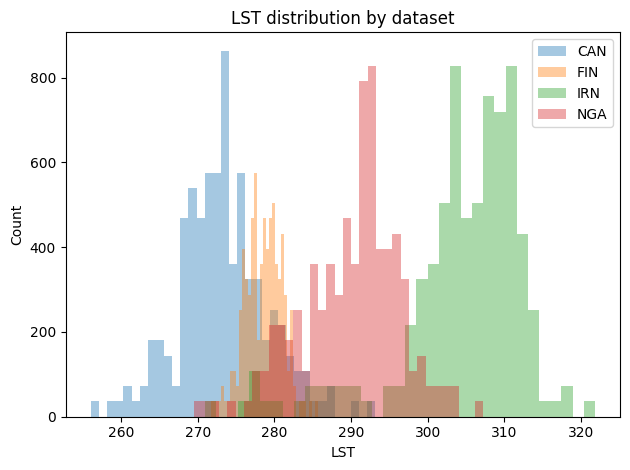

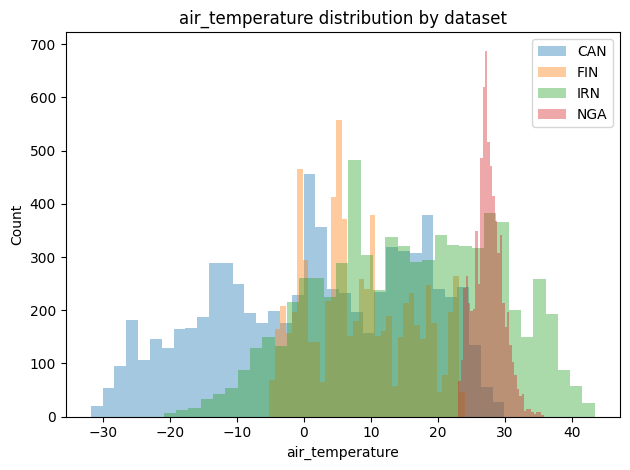

In [14]:

for t in targets:
    plt.figure()
    for k in dfs.keys():
        vals = combined.loc[combined["dataset"] == k, t].dropna()
        plt.hist(vals, bins=35, alpha=0.4, label=k)
    plt.title(f"{t} distribution by dataset")
    plt.xlabel(t)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6) Relationship between targets (air_temperature vs LST)

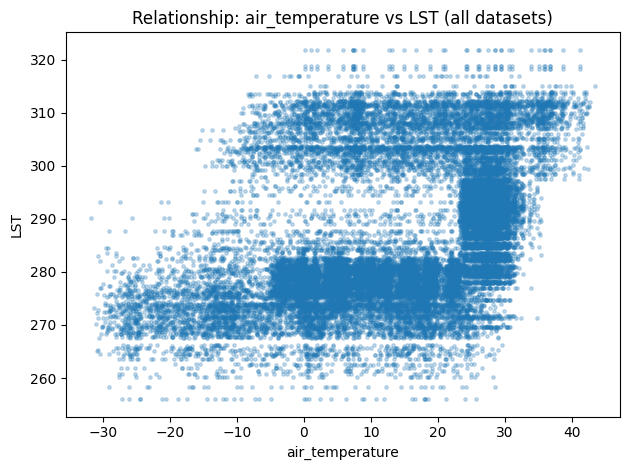

In [15]:

plt.figure()
plt.scatter(combined["air_temperature"], combined["LST"], s=6, alpha=0.25)
plt.title("Relationship: air_temperature vs LST (all datasets)")
plt.xlabel("air_temperature")
plt.ylabel("LST")
plt.tight_layout()
plt.show()


## 7) Missingness (targets + key predictors)
Customize `key_predictors` if your dataset contains more features.

In [16]:

key_predictors = ["NDVI","NDBI","MNDWI","SAVI","albedo","elevation","wind_speed","humidity","precipitation","cloud_cover_low","LandCover"]
cols_for_missing = ["dataset"] + [c for c in targets + key_predictors if c in combined.columns]

miss = (
    combined[cols_for_missing].isna()
    .groupby(combined["dataset"]).mean().T
    .reset_index(names="column")
)
display(miss)


dataset,column,CAN,FIN,IRN,NGA
0,dataset,0.0,0.0,0.0,0.0
1,LST,0.0,0.0,0.0,0.0
2,air_temperature,0.0,0.0,0.0,0.0
3,NDVI,0.0,0.0,0.0,0.0
4,NDBI,0.0,0.0,0.0,0.0
5,MNDWI,0.0,0.0,0.0,0.0
6,SAVI,0.0,0.0,0.0,0.0
7,wind_speed,0.0,0.0,0.0,0.0
8,humidity,0.0,0.0,0.0,0.0
9,precipitation,0.0,0.0,0.0,0.0


## 8) Correlations with each target (combined + by dataset)
We report the strongest absolute correlations for quick signal checks.

In [17]:

num_cols = combined.select_dtypes(include=[np.number]).columns.tolist()

def top_corr(df, target, n=15):
    corr = df[num_cols].corr(numeric_only=True)[target].dropna()
    corr = corr.drop(target, errors="ignore")
    out = (
        corr.reindex(corr.abs().sort_values(ascending=False).index)
        .head(n)
        .reset_index()
    )
    out.columns = ["feature", "corr"]
    return out

display(top_corr(combined, "LST", 20))
display(top_corr(combined, "air_temperature", 20))

rows = []
for k in dfs.keys():
    sub = combined[combined["dataset"] == k]
    for t in targets:
        top = top_corr(sub, t, 12)
        top.insert(0, "dataset", k)
        top.insert(1, "target", t)
        rows.append(top)

top_corr_by_ds = pd.concat(rows, ignore_index=True)
display(top_corr_by_ds)


,feature,corr
0,NDBI,0.735919
1,longitude,0.678629
2,Elevation,0.527223
3,MNDWI,-0.519592
4,humidity,-0.495013
5,latitude,-0.453353
6,air_temperature,0.416204
7,cloud_cover_low,-0.378457
8,NDVI,-0.367501
9,SAVI,-0.367500


,feature,corr
0,latitude,-0.606353
1,LST,0.416204
2,cloud_cover_low,-0.404123
3,longitude,0.352967
4,NDBI,0.282118
5,MNDWI,-0.256219
6,humidity,-0.256109
7,LandCover,0.192821
8,Elevation,-0.074204
9,precipitation,0.063176


,dataset,target,feature,corr
0,CAN,LST,MNDWI,-0.470692
1,CAN,LST,Albedo,-0.396508
2,CAN,LST,NDBI,0.374235
3,CAN,LST,NDVI,0.335324
4,CAN,LST,SAVI,0.335324
...,...,...,...,...
91,NGA,air_temperature,LandCover,0.014672
92,NGA,air_temperature,Albedo,-0.008593
93,NGA,air_temperature,latitude,0.004427
94,NGA,air_temperature,MNDWI,0.004171


## 9) LandCover analysis (if available)
This produces counts and boxplots of each target by LandCover for each dataset.

,dataset,LandCover,count,pct_within_dataset
0,CAN,10.0,4104,57.286432
6,CAN,80.0,1044,14.572864
1,CAN,20.0,900,12.562814
7,CAN,90.0,432,6.030151
2,CAN,30.0,360,5.025126
3,CAN,40.0,216,3.015075
4,CAN,50.0,36,0.502513
5,CAN,60.0,36,0.502513
8,CAN,100.0,36,0.502513
9,FIN,10.0,5328,74.000000


C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


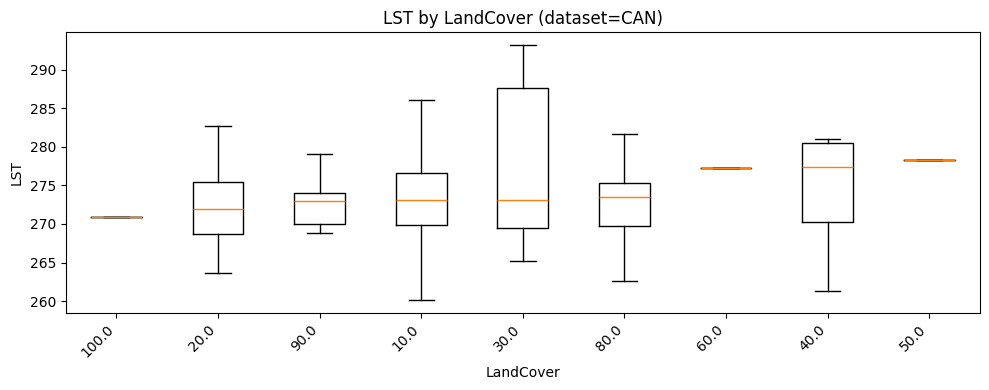

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


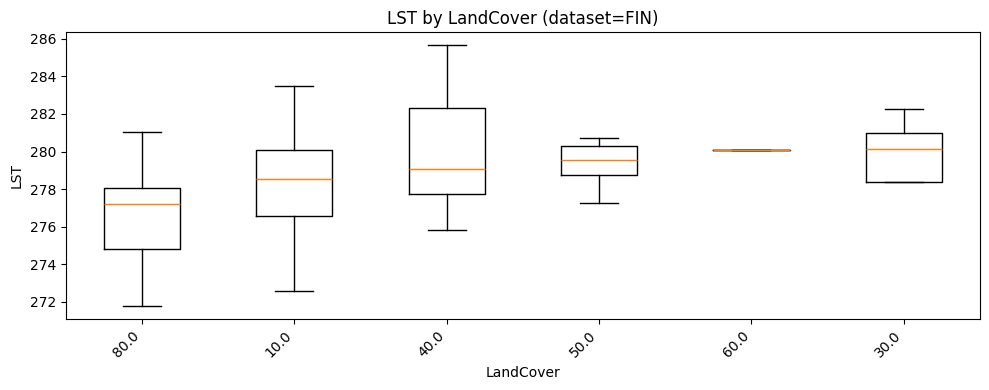

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


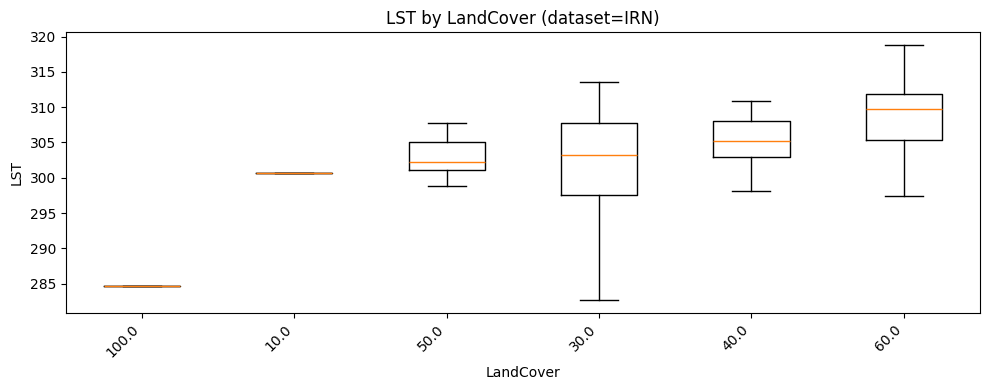

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


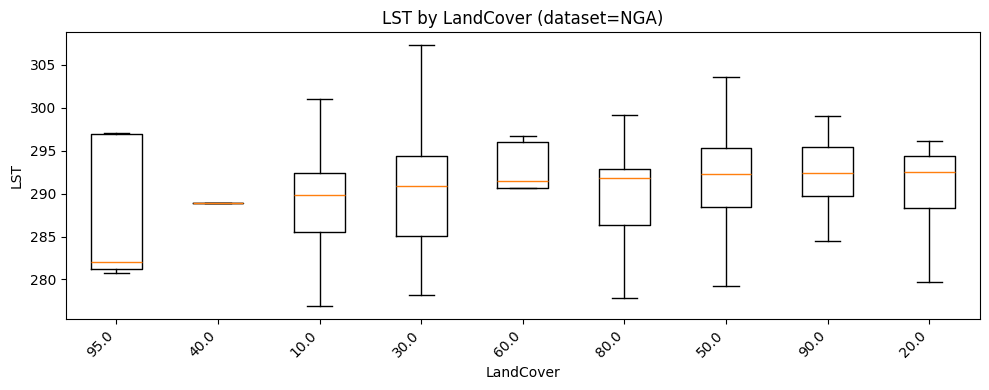

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


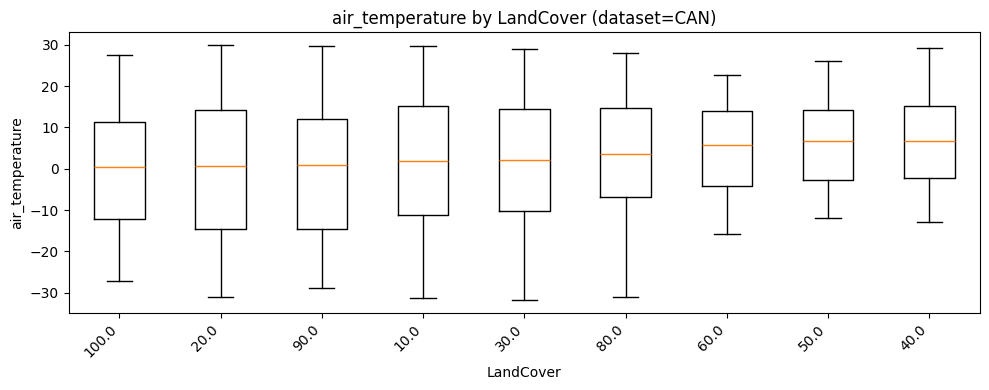

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


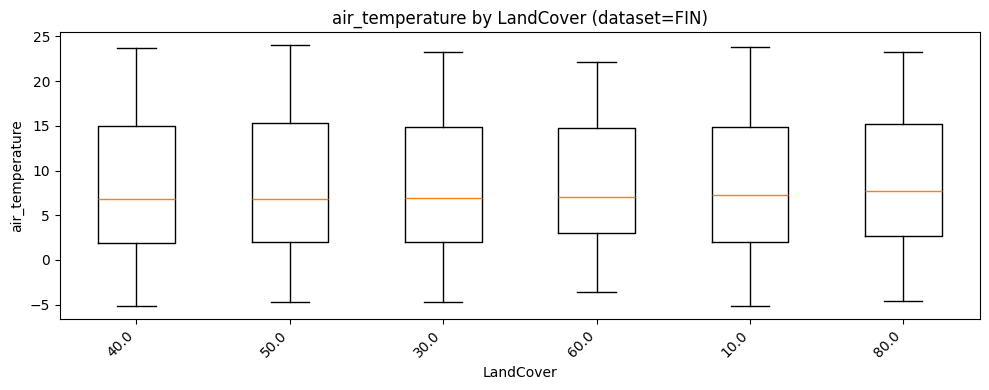

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


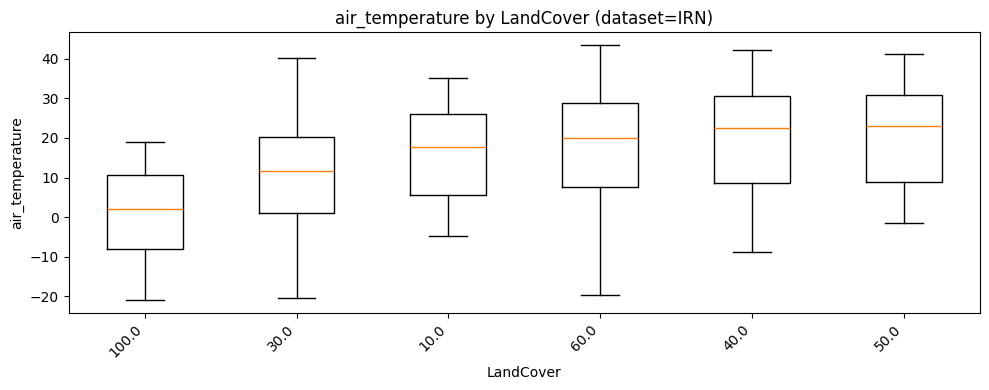

C:\Users\CHUKA\AppData\Local\Temp\ipykernel_17628\3016901783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered, showfliers=False)


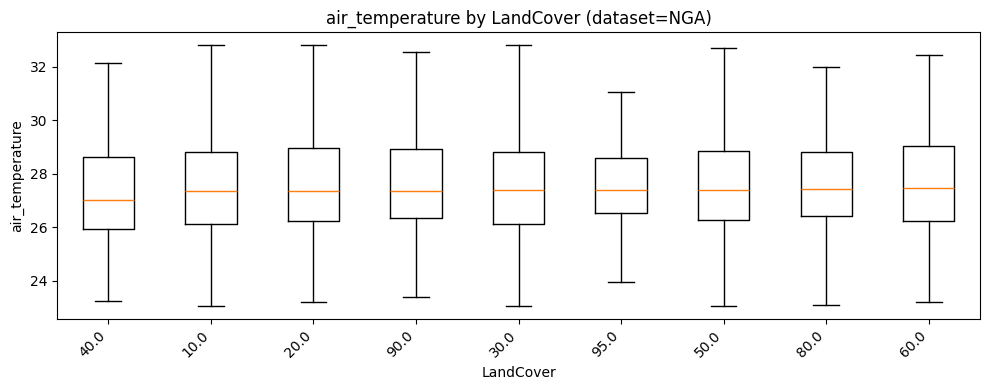

In [18]:

if "LandCover" in combined.columns:
    lc_counts = combined.groupby(["dataset", "LandCover"]).size().reset_index(name="count")
    lc_counts["pct_within_dataset"] = lc_counts["count"] / lc_counts.groupby("dataset")["count"].transform("sum") * 100
    display(lc_counts.sort_values(["dataset", "count"], ascending=[True, False]))

    for t in targets:
        for k in dfs.keys():
            sub = combined[(combined["dataset"] == k) & (~combined[t].isna()) & (~combined["LandCover"].isna())]
            if sub.empty:
                continue

            # Order LandCover categories by median target
            med = sub.groupby("LandCover")[t].median().sort_values()
            ordered = med.index.tolist()

            data = [sub.loc[sub["LandCover"] == lc, t].values for lc in ordered]

            plt.figure(figsize=(10, 4))
            plt.boxplot(data, labels=ordered, showfliers=False)
            plt.title(f"{t} by LandCover (dataset={k})")
            plt.xlabel("LandCover")
            plt.ylabel(t)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
else:
    print("No LandCover column found.")


## 10) Feature vs Target scatterplots
Scatterplots for common indices (if present) against each target, colored by dataset.

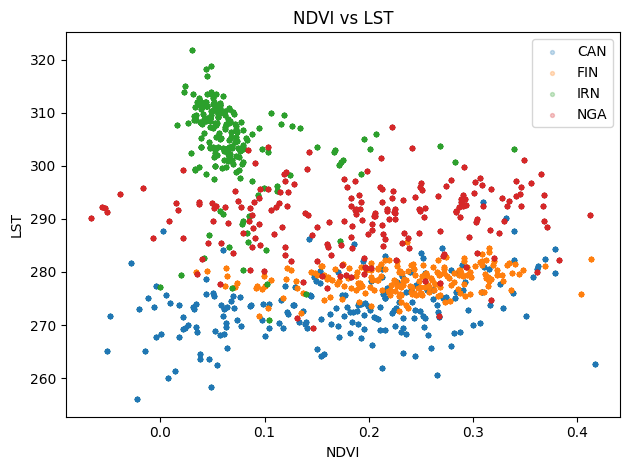

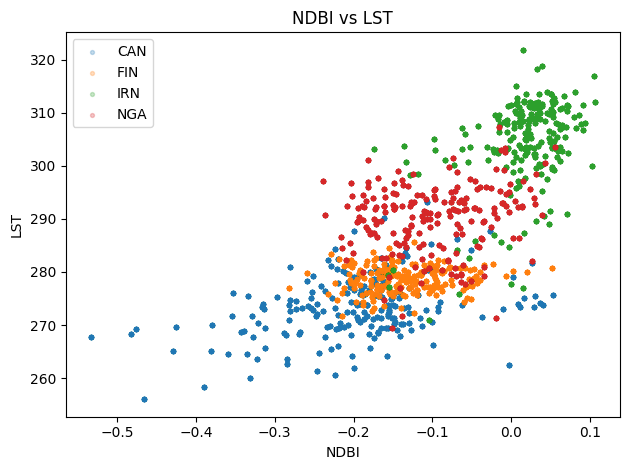

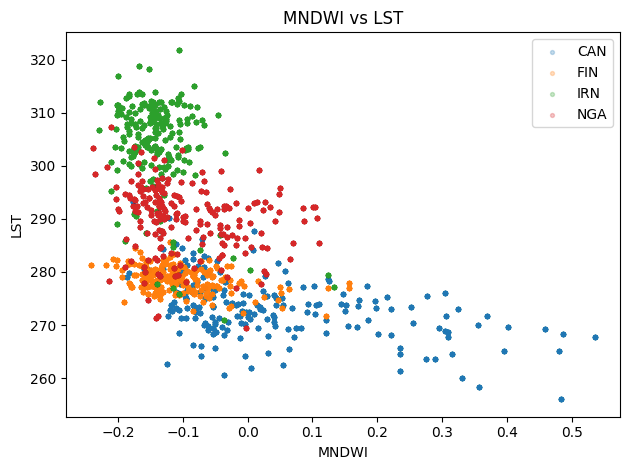

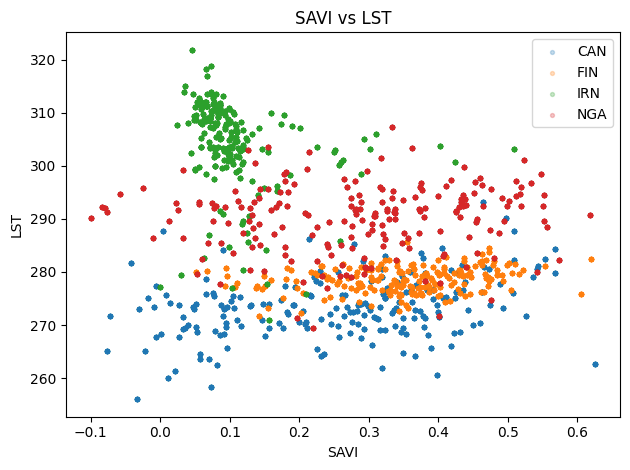

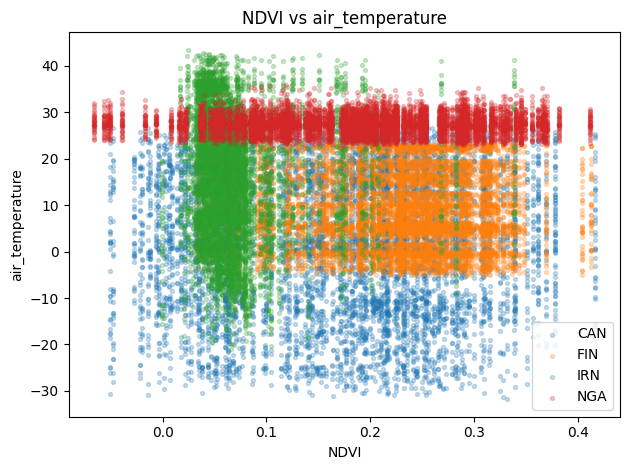

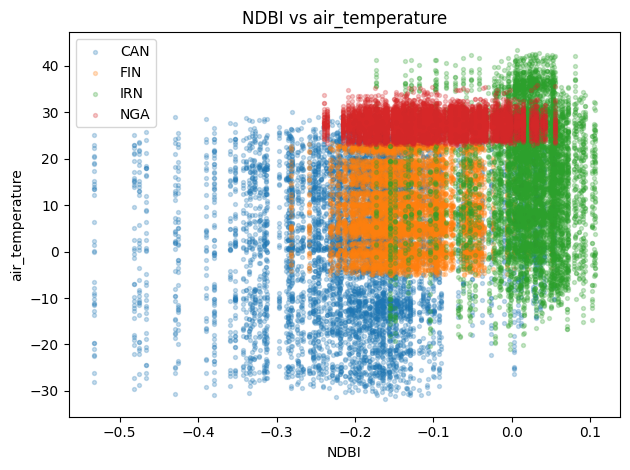

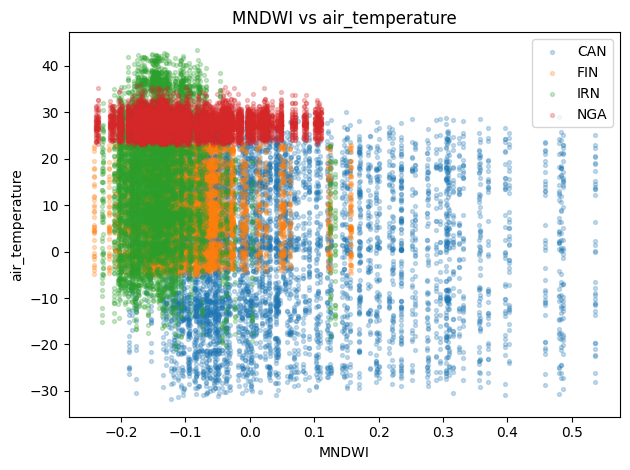

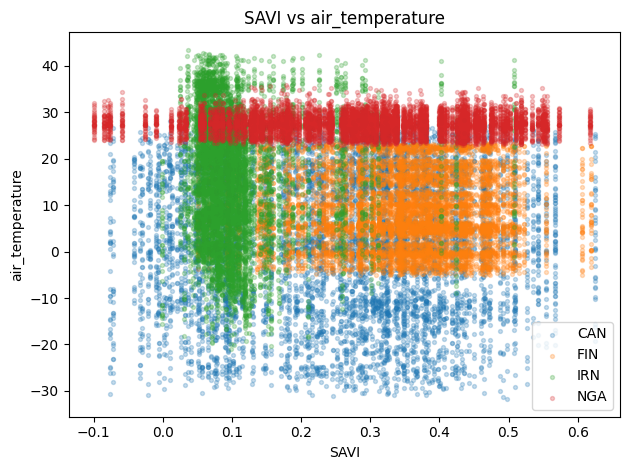

In [19]:

pairs = [f for f in ["NDVI","NDBI","MNDWI","SAVI","albedo","elevation"] if f in combined.columns]

for t in targets:
    for f in pairs:
        plt.figure()
        for k in dfs.keys():
            sub = combined.loc[combined["dataset"] == k, [f, t]].dropna()
            if len(sub):
                plt.scatter(sub[f], sub[t], s=8, alpha=0.25, label=k)
        plt.title(f"{f} vs {t}")
        plt.xlabel(f)
        plt.ylabel(t)
        plt.legend()
        plt.tight_layout()
        plt.show()


## 11) Export summary table
This saves a simple summary of target ranges by dataset for use in your report.

In [ ]:

out_path = Path("EDA_summary_targets_by_dataset.csv")
range_tbl.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())
